<a href="https://colab.research.google.com/github/amit20kr/Coal_Rock-identification/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Set Up***

In [ ]:
import os
import subprocess
import sys
import torch

def setup_colab_env():
    print(" Setting up Colab Environment for PCViT Project...")

    # Install Required Libraries
    print("   -> Installing dependencies (scipy, sklearn, matplotlib)...")
    packages = ["scipy", "scikit-learn", "matplotlib", "pandas", "numpy"]
    for package in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])



if __name__ == "__main__":
    setup_colab_env()

 Setting up Colab Environment for PCViT Project...
   -> Installing dependencies (scipy, sklearn, matplotlib)...


# ***Searching the Dataset***

In [ ]:
import glob
import os

# CELL 2: LOCATE THE DATASET

print(" Searching for dataset files...")

found_files = glob.glob("/content/drive/MyDrive/**/Thin coal.csv", recursive=True)

if len(found_files) > 0:
    actual_path = os.path.dirname(found_files[0])
    print(f"\n FOUND DATASET AT: {actual_path}")
else:
    print("\n Could not find 'Thin coal.csv'.")

# Optional: List contents of the specific folder you thought it was
test_path = "/content/drive/MyDrive/Spectroscopy_dataset/Spectra"
if os.path.exists(test_path):
    print(f"\nContents of {test_path}:")
    print(os.listdir(test_path)[:5]) # Show first 5 files
else:
    print(f"\nThe path '{test_path}' does not exist.")

 Searching for dataset files...

 FOUND DATASET AT: /content/drive/MyDrive/Coal_Project0/Spectroscopy_dataset/Spectra

The path '/content/drive/MyDrive/Spectroscopy_dataset/Spectra' does not exist.


# ***Loading the dataset***

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm

# CONFIGURATION
DATASET_PATH = "/content/drive/MyDrive/coalrock_project/Spectroscopy_dataset/Spectra"
EXPECTED_BANDS = 1501

COAL_CLASSES = [
    'Anthracite coal grade 1', 'Anthracite coal grade 2', 'Lean coal',
    'Lean-thin coal', 'Thin coal', 'Coking coal', 'Fat coal',
    '0.3 coking coal', 'Gas-fat coal', 'Gas coal',
    'Lignite coal grade 1', 'Lignite coal grade 2'
]

ROCK_CLASSES = [
    'Argillaceous limestone 1', 'Argillaceous limestone 2', 'Siltstone 1',
    'Siltstone 2', 'Clay', 'Carbonaceous shale', 'Fine-grained sandstone',
    'Black shale 1', 'Black shale 2', 'Medium-grained sandstone',
    'Arenaceous shale 1', 'Arenaceous shale 2'
]

ALL_CLASSES = COAL_CLASSES + ROCK_CLASSES

def load_data_expert(path):
    print(f" STARTING INGESTION FROM: {path}")

    # 1. Find all CSVs recursively
    all_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
    if not all_files:
        print(f" ERROR: No CSV files found. Check path.")
        return {}

    # {'Class Name': [Array of shape (N_samples, 1501)]
    dataset = {cls: [] for cls in ALL_CLASSES}
    stats = {'processed': 0, 'skipped': 0, 'samples': 0}

    # Processing Loop
    for filepath in tqdm(all_files, desc="Ingesting Files"):
        try:
            # CLASS MATCHING
            filename = os.path.basename(filepath)
            matched_class = None

            clean_fname = filename.lower().replace(" ", "").replace("_", "")

            for cls in ALL_CLASSES:
                clean_cls = cls.lower().replace(" ", "").replace("_", "")
                if clean_cls in clean_fname:
                    matched_class = cls
                    break

            if not matched_class:
                # print(f" Skipping unmatched file: {filename}")
                stats['skipped'] += 1
                continue

            # LOADING
            df_raw = pd.read_csv(filepath, header=None, low_memory=False)
            df_numeric = df_raw.apply(pd.to_numeric, errors='coerce')

            # Keep only rows/cols that are mostly numbers
            # This kills the "Angle/Degree" rows automatically
            valid_rows = df_numeric.notna().sum(axis=1) > (df_raw.shape[1] * 0.5)
            df_clean = df_numeric[valid_rows].dropna(axis=1, how='all') # Drop empty cols

            if df_clean.empty:
                stats['skipped'] += 1
                continue

            # ORIENTATION NORMALIZATION
            # We want shape: (N_samples, N_bands)
            vals = df_clean.values

            dim0, dim1 = vals.shape

            if abs(dim0 - EXPECTED_BANDS) < abs(dim1 - EXPECTED_BANDS):
                vals = vals.T
            n_samples, n_bands = vals.shape

            final_data = None

            if n_bands == EXPECTED_BANDS:
                final_data = vals
            elif n_bands > EXPECTED_BANDS:
                final_data = vals[:, :EXPECTED_BANDS]
            else:
                stats['skipped'] += 1
                continue

            if final_data is not None:
                dataset[matched_class].append(final_data)
                stats['processed'] += 1
                stats['samples'] += final_data.shape[0]

        except Exception as e:
            stats['skipped'] += 1
            continue

    print("\n INGESTION COMPLETE")
    print(f"   Files Processed: {stats['processed']}")
    print(f"   Files Skipped:   {stats['skipped']}")
    print(f"   Total Samples:   {stats['samples']}")

    return dataset

data_dict = load_data_expert(DATASET_PATH)

# VERIFICATION STEP
for k, v in data_dict.items():
    if len(v) > 0:
        combined = np.vstack(v)
        print(f"🔍 Verification - {k}: {combined.shape} (Should be N x 1501)")
        break

 STARTING INGESTION FROM: /content/drive/MyDrive/coalrock_project/Spectroscopy_dataset/Spectra


Ingesting Files: 100%|██████████| 24/24 [00:17<00:00,  1.41it/s]


 INGESTION COMPLETE
   Files Processed: 24
   Files Skipped:   0
   Total Samples:   10520
🔍 Verification - Anthracite coal grade 1: (419, 1501) (Should be N x 1501)


# ***Graph Plotting***

 Visualizing 1501 bands (1000-2500nm).


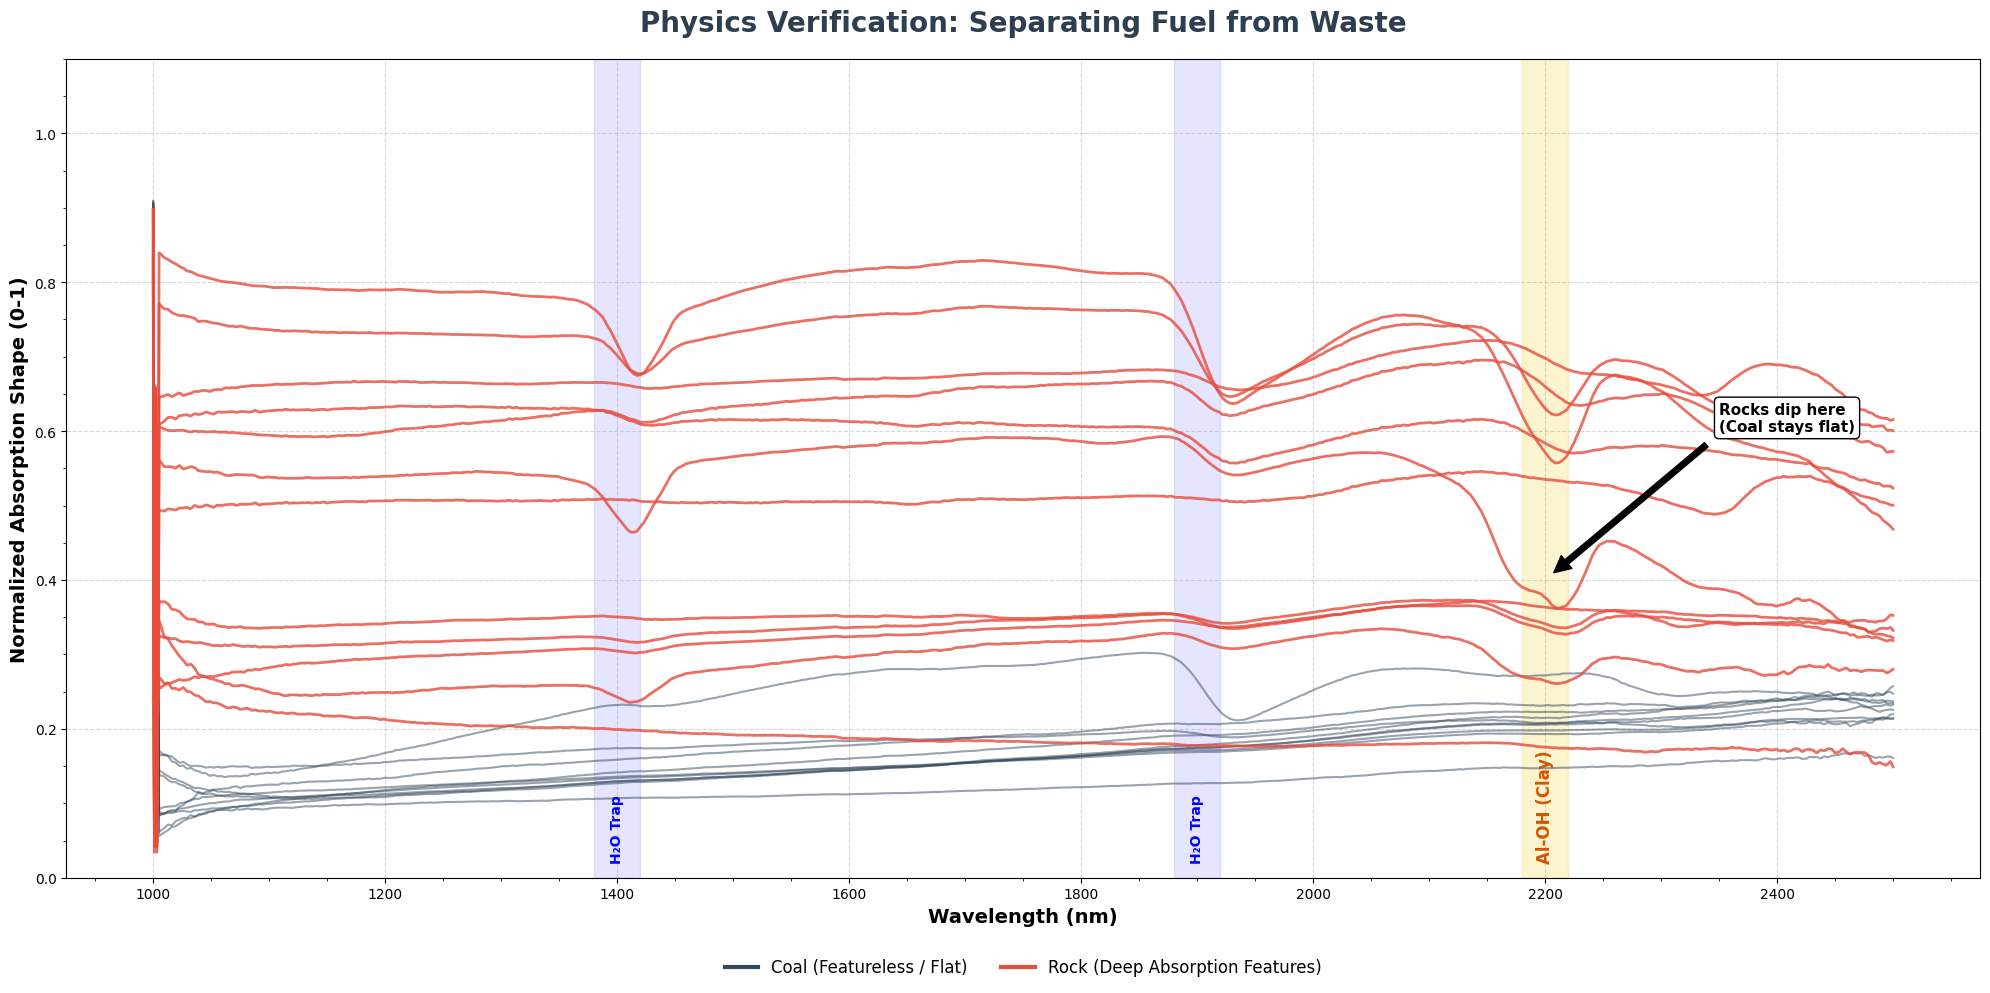

 Physics-Enhanced Plot Generated.


In [ ]:
# SPECTRAL VISUALIZATION (Graph)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

# SAFETY CHECK
if 'data_dict' not in locals() or not any(len(v) > 0 for v in data_dict.values()):
    print(" ERROR: Data dictionary is empty. Run the Loader Cell first.")
else:
    fig, ax = plt.subplots(figsize=(20, 10), facecolor='#ffffff')

    # WAVELENGTH
    first_valid = next(k for k, v in data_dict.items() if len(v) > 0)
    n_bands = data_dict[first_valid][0].shape[1]
    wavelengths = np.linspace(1000, 2500, n_bands)
    print(f" Visualizing {n_bands} bands (1000-2500nm).")

    plotted_count = 0
    sorted_classes = COAL_CLASSES + ROCK_CLASSES

    for cls in sorted_classes:
        if cls not in data_dict or not data_dict[cls]:
            continue

        try:
            arr = np.vstack(data_dict[cls])
            arr = pd.DataFrame(arr).apply(pd.to_numeric, errors='coerce').values


            row_stds = np.nanstd(arr, axis=1)
            clean_arr = arr[row_stds > 1e-5]

            if len(clean_arr) == 0: clean_arr = arr
            mins = np.nanmin(clean_arr, axis=1)[:, None]
            maxs = np.nanmax(clean_arr, axis=1)[:, None]
            norm_arr = (clean_arr - mins) / (maxs - mins + 1e-8)

            mu = np.nanmean(norm_arr, axis=0)

            if cls in COAL_CLASSES:
                color = '#34495e' # Black(Coal)
                lw = 1.5
                alpha = 0.5
                zorder = 2
                linestyle = '-'
            else:
                color = '#e74c3c' # Red(Rock)
                lw = 2.0
                alpha = 0.8
                zorder = 3
                linestyle = '-'

            # F. Plot
            ax.plot(wavelengths, mu, color=color, linewidth=lw, alpha=alpha, zorder=zorder, linestyle=linestyle)
            plotted_count += 1

        except Exception as e:
            print(f"❌ Error plotting {cls}: {e}")

    # The Water Bands (1400 & 1900)
    for w in [1400, 1900]:
        ax.axvspan(w-20, w+20, color='blue', alpha=0.1, zorder=1)
        ax.text(w, 0.02, "H₂O Trap", ha='center', va='bottom', fontsize=10,
                color='blue', fontweight='bold', rotation=90)

    # The Clay Trap (2200nm)
    ax.axvspan(2180, 2220, color='#f1c40f', alpha=0.2, zorder=1)
    ax.text(2200, 0.02, "Al-OH (Clay)", ha='center', va='bottom', fontsize=12,
            color='#d35400', fontweight='bold', rotation=90)

    # Add an arrow
    ax.annotate('Rocks dip here\n(Coal stays flat)', xy=(2200, 0.4), xytext=(2350, 0.6),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=11, fontweight='bold', bbox=dict(boxstyle="round", fc="w"))

    ax.set_title(f"Physics Verification: Separating Fuel from Waste",
                 fontsize=20, fontweight='bold', color='#2c3e50', pad=20)
    ax.set_xlabel("Wavelength (nm)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Normalized Absorption Shape (0-1)", fontsize=14, fontweight='bold')

    # Custom Legend
    coal_proxy = mlines.Line2D([], [], color='#34495e', linewidth=3, label='Coal (Featureless / Flat)')
    rock_proxy = mlines.Line2D([], [], color='#e74c3c', linewidth=3, label='Rock (Deep Absorption Features)')

    ax.legend(handles=[coal_proxy, rock_proxy], loc='upper center', fontsize=12, ncol=2,
              bbox_to_anchor=(0.5, -0.08), frameon=False)

    ax.set_ylim(0, 1.1)
    ax.grid(True, which='major', linestyle='--', alpha=0.5)
    ax.minorticks_on()

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/coalrock_project/results/EDA_GraphPlotting.png', dpi=300)
    plt.show()
    print(" Physics-Enhanced Plot Generated.")

📊 Auto-detected spectral resolution: 1506 bands.


/tmp/ipython-input-1039099902.py:37: RuntimeWarning: Mean of empty slice
  mean_spec = np.nanmean(spectra_clean, axis=0)


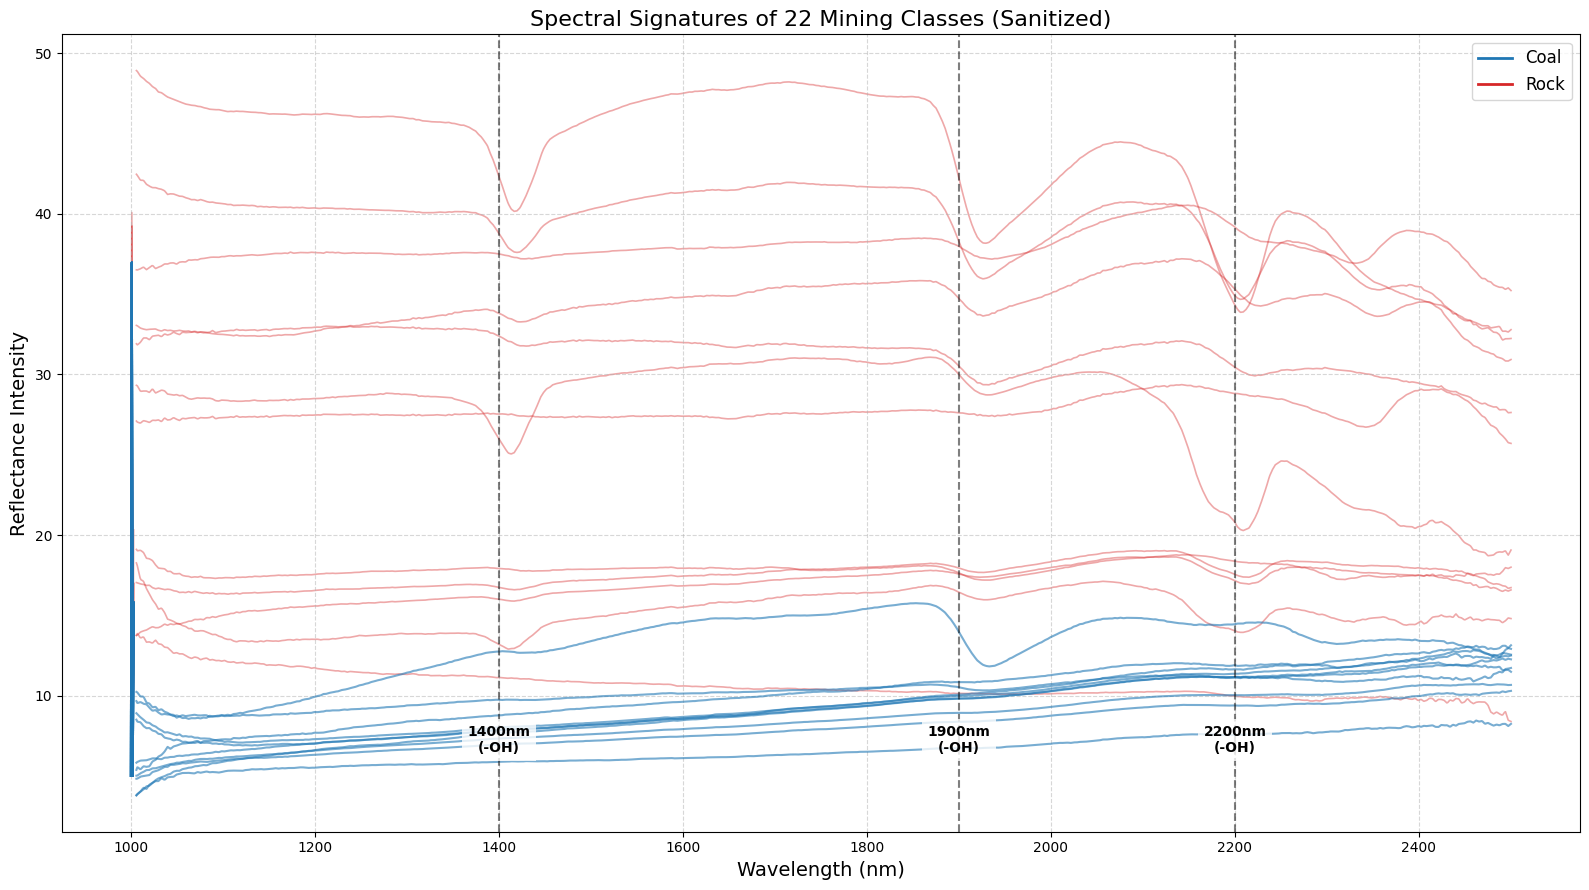

✅ Plot Generated Successfully.


In [ ]:
# CELL 4: ROBUST & SANITIZED PLOTTING
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

# 1. Safety Check
if 'data_dict' not in locals() or not any(len(v) > 0 for v in data_dict.values()):
    print("❌ data_dict is empty. Please re-run the Loader Cell first.")
else:
    plt.figure(figsize=(16, 9))

    # 2. Dynamic Wavelength Detection
    # We find the first valid array to set the X-axis
    first_valid_key = next(k for k, v in data_dict.items() if len(v) > 0)
    # Check shape of the first sample
    sample_shape = data_dict[first_valid_key][0].shape[0]
    print(f"📊 Auto-detected spectral resolution: {sample_shape} bands.")

    wavelengths = np.linspace(1000, 2500, sample_shape)

    # 3. Plotting Loop with Sanitization
    plotted_count = 0
    for cls, spectra in data_dict.items():
        if len(spectra) > 0:
            try:
                # Stack samples
                spectra_array = np.vstack(spectra)

                # --- THE FIX: FORCE CONVERT TO FLOAT ---
                # This converts strings like "0.45" to numbers 0.45
                # 'errors=coerce' turns unreadable text (like headers) into NaN
                spectra_df = pd.DataFrame(spectra_array)
                spectra_clean = spectra_df.apply(pd.to_numeric, errors='coerce').values

                # Compute Mean (ignoring NaNs that resulted from bad text)
                mean_spec = np.nanmean(spectra_clean, axis=0)

                # Color Logic
                if cls in COAL_CLASSES:
                    c = '#1f77b4' # Blue
                    z = 2
                    alpha = 0.6
                    lw = 1.5
                else:
                    c = '#d62728' # Red
                    z = 1
                    alpha = 0.4
                    lw = 1.2

                plt.plot(wavelengths, mean_spec, color=c, alpha=alpha, linewidth=lw, zorder=z)
                plotted_count += 1

            except Exception as e:
                print(f"⚠️ Could not plot class '{cls}': {e}")
                continue

    # 4. Physics Markers
    valleys = [1400, 1900, 2200]
    for v in valleys:
        plt.axvline(x=v, color='black', linestyle='--', alpha=0.5)
        plt.text(v, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0])*0.1,
                 f'{v}nm\n(-OH)', ha='center', fontsize=10,
                 fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # 5. Formatting
    plt.title(f'Spectral Signatures of {plotted_count} Mining Classes (Sanitized)', fontsize=16)
    plt.xlabel('Wavelength (nm)', fontsize=14)
    plt.ylabel('Reflectance Intensity', fontsize=14)
    plt.grid(True, which='major', linestyle='--', alpha=0.5)

    coal_line = mlines.Line2D([], [], color='#1f77b4', linewidth=2, label='Coal')
    rock_line = mlines.Line2D([], [], color='#d62728', linewidth=2, label='Rock')
    plt.legend(handles=[coal_line, rock_line], loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.savefig('01_spectral_validation_master.png', dpi=300)
    plt.show()
    print("✅ Plot Generated Successfully.")